In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

#Zadanie 1
df_original = pd.read_csv('zamowienia.csv', sep=';', decimal='.')

df_original['Data zamowienia'] = pd.to_datetime(df_original['Data zamowienia'])
print("Wartości brakujące przed zmianami:\n", df_original.isnull().sum())
df_missing = df_original.copy()
n_rows = len(df_missing)
idx_sprzedawca = df_missing.sample(frac=0.1, random_state=42).index
df_missing.loc[idx_sprzedawca, 'Sprzedawca'] = 'BRAK'
idx_id = df_missing.sample(frac=0.05, random_state=42).index
df_missing.loc[idx_id, 'idZamowienia'] = np.nan
idx_data = df_missing.sample(frac=0.2, random_state=42).index
df_missing.loc[idx_data, 'Data zamowienia'] = np.nan
idx_utarg = df_missing.sample(frac=0.15, random_state=42).index
df_missing.loc[idx_utarg, 'Utarg'] = np.nan
print("Wartości brakujące po wprowadzeniu zmian:\n", df_missing.isnull().sum())

Wartości brakujące przed zmianami:
 Kraj               0
Sprzedawca         0
Data zamowienia    0
idZamowienia       0
Utarg              0
dtype: int64
Wartości brakujące po wprowadzeniu zmian:
 Kraj                 0
Sprzedawca           0
Data zamowienia    160
idZamowienia        40
Utarg              120
dtype: int64


In [16]:
#Zadanie 2
df_missing['idZamowienia'] = df_missing['idZamowienia'].fillna(0)
df_missing['Data zamowienia'] = df_missing['Data zamowienia'].ffill()
df_missing['Utarg'] = df_missing.groupby('Kraj')['Utarg'].transform(lambda x: x.fillna(x.mean()))
print(df_missing.isnull().sum())

Kraj               0
Sprzedawca         0
Data zamowienia    0
idZamowienia       0
Utarg              0
dtype: int64


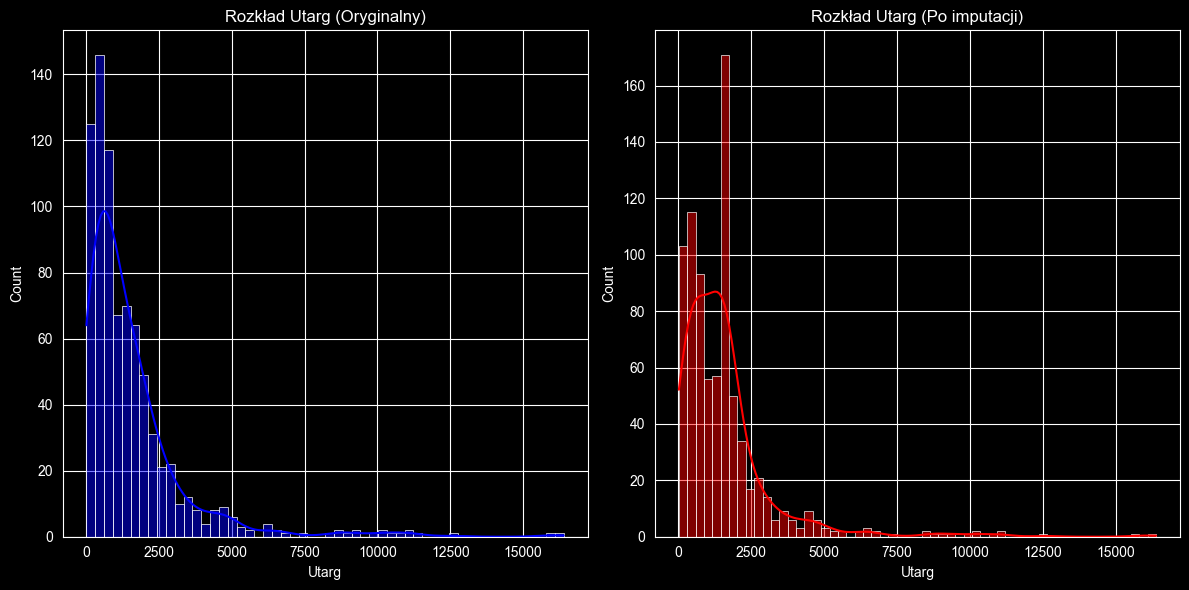

In [17]:
#Zadanie 3
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_original['Utarg'], kde=True, color='blue')
plt.title('Rozkład Utarg (Oryginalny)')
plt.subplot(1, 2, 2)
sns.histplot(df_missing['Utarg'], kde=True, color='red')
plt.title('Rozkład Utarg (Po imputacji)')
plt.tight_layout()
plt.show()

In [30]:
#Zadanie 4
url = "https://github.com/YBI-Foundation/Dataset/blob/main/Diabetes%20Missing%20Data.csv"
diabetes = pd.read_csv(url)
diabetes.columns = diabetes.columns.str.strip()
def group_knn_impute(df, group_col, n_neighbors=5):
    num_cols = df.select_dtypes(include=[np.number]).columns
    def impute_chunk(group):
        if len(group) <= n_neighbors:
            return group
        imputer = KNNImputer(n_neighbors=n_neighbors)
        group[num_cols] = imputer.fit_transform(group[num_cols])
        return group
    return df.groupby(group_col, group_keys=False).apply(impute_chunk)
diabetes_by_class = group_knn_impute(diabetes.copy(), 'Class')
diabetes_age = diabetes.copy()
bins = [0, 25, 45, 120]
labels = ['Young', 'Middle', 'Senior']
diabetes_age['Age_Group'] = pd.cut(diabetes_age['Age'], bins=bins, labels=labels)
diabetes_by_age = group_knn_impute(diabetes_age, 'Age_Group')
print(diabetes_by_class.isnull().sum().sum())
print(diabetes_by_age.isnull().sum().sum())
plt.figure(figsize=(12, 6))
sns.kdeplot(diabetes['Glucose'].dropna(), label='Oryginalny (z NaN)', color='black', lw=2)
sns.kdeplot(diabetes_by_class['Glucose'], label='Imputacja wg Class', ls='--')
sns.kdeplot(diabetes_by_age['Glucose'], label='Imputacja wg Age Group', ls=':')

plt.title('Porównanie razkładu Glucose po różnych metodach imputacji KNN')
plt.legend()
plt.show()

IncompleteRead: IncompleteRead(402240 bytes read)